# AM115 Group Project - Epidemic Model Extension

by Tadhg Scannell, Kaylee Vo

## Section 0: Import, set up plt dynamics, and define functions

In [127]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from scipy.optimize import basinhopping

In [128]:
# Customize for matplotlib
# If interested in the matplotlib object hierarchy, check: https://realpython.com/python-matplotlib-guide/
plt.rcParams["axes.linewidth"] = 1
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["mathtext.default"] = "regular"

# Change font size: http://www.futurile.net/2016/02/27/matplotlib-beautiful-plots-with-style/
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["figure.titlesize"] = 20

## Section 1: Model Definition

The system of ODEs:
$$
\frac{dS}{dt} = - \frac{a(t)}{N} I S - c S + \gamma R
$$

$$
\frac{dE}{dt} = \frac{a(t)}{N} I S - \nu E
$$

$$
\frac{dI}{dt} = \nu E - b I - \eta I
$$

$$
\frac{dR}{dt} = b I + c S - \gamma R
$$

$$
\frac{dD}{dt} = \eta I
$$

Parameters:
$$
a(t) = pt \cdot nc(t)
$$
$$
nc(t) = m_{min} + (m_{max} - m_{min}) \cdot \exp[s \cdot \max(t - t_{start},0)].
$$

Here, the fixed quantities are $m_{max}$ is the maximum number of contacts an individual can have, and $t_{start}$ denotes the start of the lockdown. Both are fixed quantities. The decision variables are $m_{min} \in \mathbb{R}$, the minimum number of contacts permitted or the strength of the lockdown, and $s \in \mathbb{R}$, the speed or sharpness of the lockdown. The more negative $s$ is, the sharper the lockdown. The more positive $s$ is, the slower the lockdown.

In [129]:
def nc_func(t, sharpness, min_val=1, max_val=6, lockdown_start=7):
    """
    Calculate contact rate nc with exponential decay after lockdown_start.

    Args:
        t: Current time
        sharpness: Negative value controlling decay speed (more negative = faster lockdown)
        min_val: Minimum contact rate (lockdown strength)
        max_val: Maximum contact rate (normal activity)
        lockdown_start: Fixed time when lockdown begins (default=5)

    Returns:
        Contact rate between min_val and max_val
    """
    t0 = max(t - lockdown_start, 0)
    decay = np.exp(sharpness * t0)
    return min_val + (max_val - min_val) * decay

In [130]:
def seird(t, X, pt, b, c, eta, gamma, nu, N, lockdown=False, sharpness=None):
    if lockdown:
        nc_val = nc_func(t, sharpness)
    else:
        nc_val = 6

    a = pt * nc_val
    s, e, i, r, d = X
    ds = -a * s * i / N - c * s + gamma * r
    de = a * s * i / N - nu * e
    di = nu * e - b * i - eta * i
    dr = b * i + c * s - gamma * r
    dd = eta * i
    return [ds, de, di, dr, dd]

### Section 1i. Lockdown Function

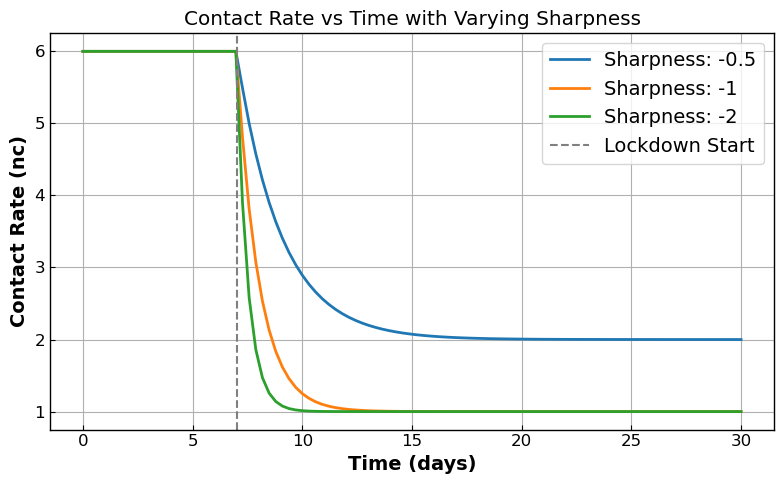

In [131]:
ts = np.linspace(0, 30, 100)

plt.figure(figsize=(8, 5))
for sharpness in [-0.5, -1, -2]:
    min_val = 1
    if sharpness > -1:
        min_val = 2  # Increase minimum value for sharper lockdowns
    ncs = [nc_func(ti, sharpness, min_val) for ti in ts]

    plt.plot(ts, ncs, label=f"Sharpness: {sharpness}", linewidth=2)
plt.xlabel("Time (days)")
plt.ylabel("Contact Rate (nc)")
plt.title("Contact Rate vs Time with Varying Sharpness")
plt.axvline(x=7, color="gray", linestyle="--", label="Lockdown Start")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("./plots/lockdown_function.png")
plt.show()

### Section 1ii. Parameters

For this subsection, we define the parameters and provide sources for the values used. Links to the sources are provided in the markdown.

In [132]:
# Parameters
# Time span for simulation is 120 days or
# roughly 4 months
tspan = (0, 120)
t_eval = np.arange(0, 120, 0.1)

In [133]:
# Population size
N = 2e6

In [134]:
# nc ranges from 6 to 1
# vary this to match the R0
# 0.1 is around the midpoint of the range found in papers
pt = 0.1

- The probability of transmission for COVID takes on a wide range depending on the environment and length of exposure. For household transmission, $pt$ can be as high as 0.189.
- In contrast, for outdoor transmission, it can be as low as <0.01.
- Sources
    - https://pubmed.ncbi.nlm.nih.gov/35482308/
    - https://academic.oup.com/jid/article/223/4/550/6009483


In [135]:
# research found ranges from 0.03 to 0.06
b = 0.05

- From the below sources, we found a suitable range for $b$, the recovery rate.
- The range we establish is from 0.03 to 0.06. For our analysis, we will use 0.05, since it is around the midpoint of the range.
- Sources
    - https://jamanetwork.com/journals/jamanetworkopen/fullarticle/2820087
    - https://www.thelancet.com/journals/lanwpc/article/PIIS2666-6065(21)00117-6/fulltext
    - https://www.tandfonline.com/doi/full/10.1080/25765299.2022.2148439#d1e7295


In [136]:
# The vacinnation rate from 2020-2021 was around 0.013
VAX_RATE = 0.69  # per year
c = VAX_RATE / (365)
round(c, 3)

0.002

- To establish a vaccination rate, we use data from the source linked below.
- We took the percent vaccinated in Dec 2020, which was 0% and in Dec 2021, which was 69%.
- To get vaccinations per day, we divide the 69% by 365 days to get a daily rate of 0.002.
- Sources
    - https://ourworldindata.org/covid-vaccinations


In [137]:
# the death rate from infected was 0.008 but we round
# The units are in CFR
DEATH_RATE = 0.01
# Convert CFR to a rate
eta = 0.01 * b / (1 - 0.01)
round(eta, 5)

0.00051

- The death rate given in the source below is around 1% on average.

$$
CFR = \frac{\eta}{\eta + b}
$$
- Using this we can solve for $\eta$ given $b$ and the CFR (1%).
- Source
    - https://ourworldindata.org/mortality-risk-covid


In [138]:
gamma = 0.008

- From papers, a new wave appears every 4 months or 120 days
- $\gamma = \frac{1}{120} = 0.00833$

- Sources
    - https://www.nature.com/articles/s41579-023-00878-2
    - https://link.springer.com/article/10.1186/s12982-024-00140-x

In [139]:
nu = 0.22

- The sources describe the latent period as 4-5 days, so we use $\frac{1}{4.5} = 0.22$ as the rate.
- Sources
    - https://pmc.ncbi.nlm.nih.gov/articles/PMC9837419/?utm_source=chatgpt.com

In [140]:
# Hospital capacity is 0.3% of the population
hospital_capacity = N * 0.003

- The total number of beds in $913,136$ per $1000$ people in the US.
- The total population of the US is $334$ million.
- $913,136 / 334,000$ = $2.74$ beds per $1000$ people.
- Or $0.00274$ beds per person. That's how we arrive at $N * 0.003$ for hospital capacity.
- Source
    - https://www.aha.org/statistics/fast-facts-us-hospitals



In [141]:
# Add a bit more to exposed just for visualization sake
# We'll use patient zero scenario later.
X0 = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]
# Adjust this value to control lockdown sharpness
# We'll fix it for now
sharpness = -0.1

### Section 1iii. Solution Curves

In [142]:
sol = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=False, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
T, X = sol.t, sol.y

In [143]:
def plot_solution_curves(T, X, title, save_path=None):
    fig, ax = plt.subplots(figsize=(10, 6))

    labels = [
        "Susceptible",
        "Exposed",
        "Infectious",
        "Recovered",
        "Cumulative Deceased",
    ]
    # Ignore death for plotting purposes
    for i in range(4):
        plt.plot(T, X[i], label=labels[i])
    plt.xlabel("Time (Days)")
    plt.ylabel("Population (N)")
    plt.title(title)
    plt.legend(loc="upper right")
    plt.grid(True)
    if save_path:
        plt.savefig(save_path)
    plt.show()

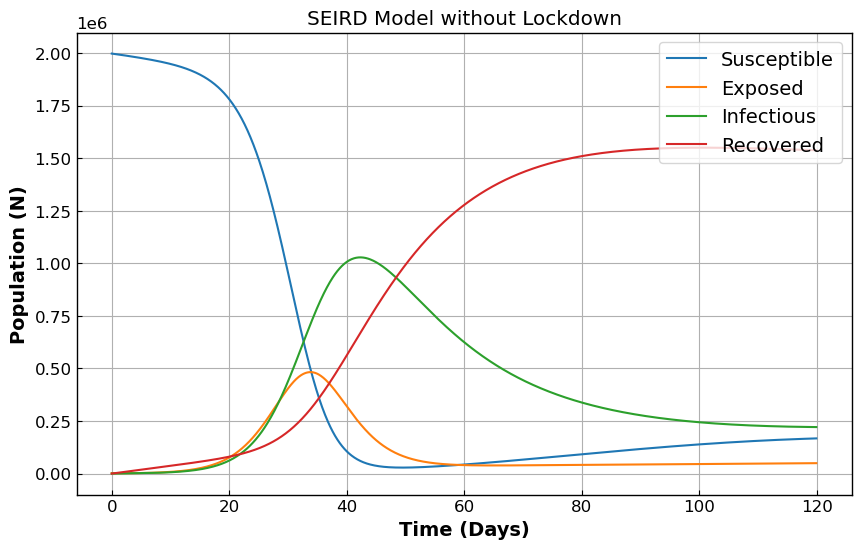

In [144]:
plot_solution_curves(
    T, X, "SEIRD Model without Lockdown", "./plots/solution_curve_nolock.png"
)

In [145]:
sol_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=True, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
T_lock, X_lock = sol_lock.t, sol_lock.y

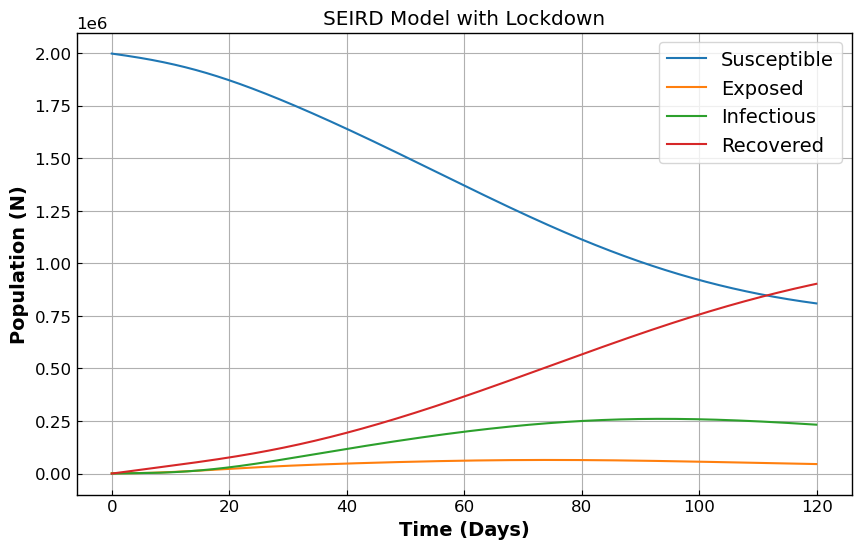

In [146]:
plot_solution_curves(
    T_lock, X_lock, "SEIRD Model with Lockdown", "./plots/solution_curve_lock.png"
)

- The results make sense. With a lockdown, the number of infected and exposed individuals is much lower than without a lockdown.


### Section 1iv. Daily Deaths

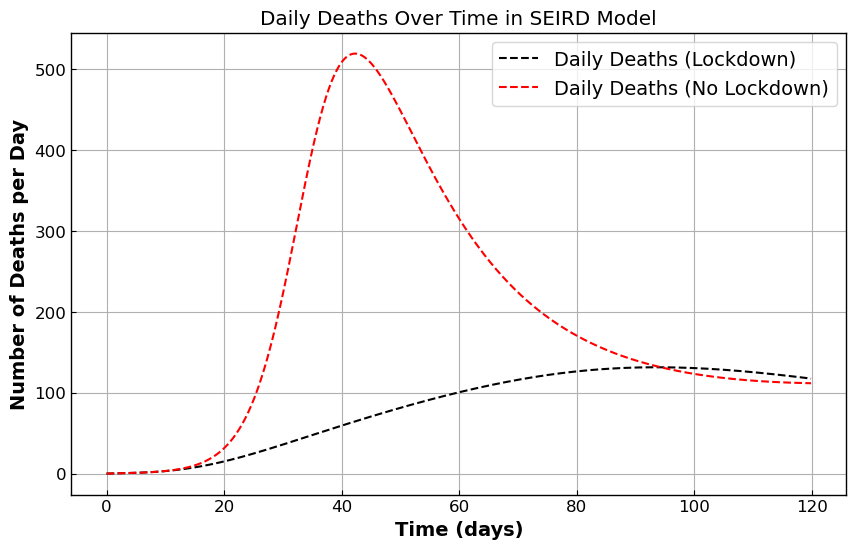

In [147]:
# This is 0.1 days as the time step
dt = t_eval[1] - t_eval[0]
daily_deaths = eta * X_lock[2]
daily_deaths_no_lockdown = eta * X[2]

plt.figure(figsize=(10, 6))
plt.plot(
    T_lock, daily_deaths, label="Daily Deaths (Lockdown)", color="black", linestyle="--"
)
plt.plot(
    T,
    daily_deaths_no_lockdown,
    label="Daily Deaths (No Lockdown)",
    color="red",
    linestyle="--",
)
plt.xlabel("Time (days)")
plt.ylabel("Number of Deaths per Day")
plt.title("Daily Deaths Over Time in SEIRD Model")
plt.legend()
plt.grid(True)
plt.savefig("./plots/daily_deaths.png")
plt.show()

- The results also make sense here. The daily deaths are much lower with a lockdown than without a lockdown.

## Section 2: Productivity Analysis

This section repeats itself. We run the same experiment for different periods. Feel free to read just one part and skip the rest.


### 2i. 120 Days of Lockdown
- $(s=-0.1 ~\text{and}~ s=-.04)$ and Without Lockdown

In [148]:
# Parameters
Number_of_days = 120
Time_step = 0.1

# Parameters for Judging Productivity
hevNoLockdown = 1  # Productivity of average individual with no lockdown
hevLockdown = 0.9  # Productivity of average individual with a lockdown
sevLockdown = 0.9  # Productivity of susceptible individual with a lockdown
eev = 0.8  # Productivity of an exposed individual
iev = -0.25  # Productivity of an infected individual
d = 0  # Productivity of a deceased individual

#### Scenario 1: Lockdown with sharpness -0.1

In [149]:
# S, E, I, R, D
X0 = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]
sharpness = -0.1

# Solve ODE with 'Radau' or 'BDF' for stiff problems
sol_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=True, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T_lock, X_lock = sol_lock.t, sol_lock.y

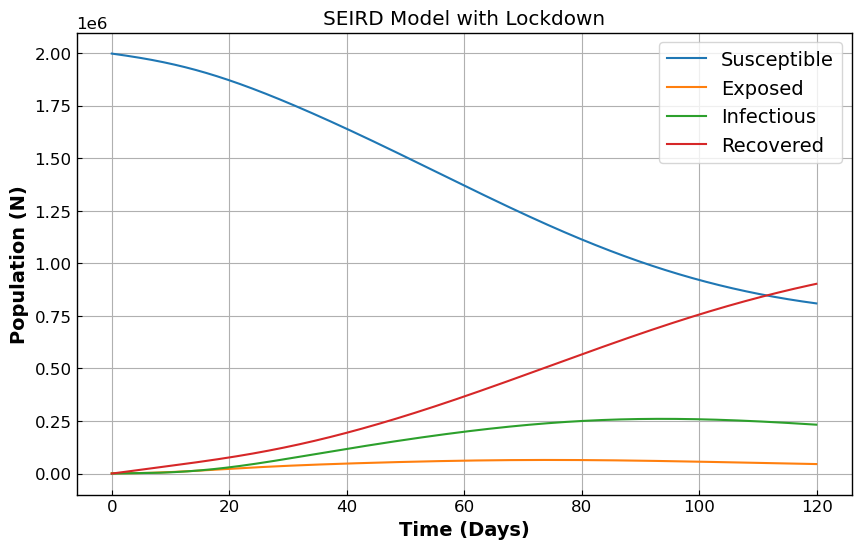

In [150]:
plot_solution_curves(T_lock, X_lock, "SEIRD Model with Lockdown")

#### Scenario 2: no Lockdown

In [151]:
# S, E, I, R, D
X0 = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]

# Solve ODE with 'Radau' or 'BDF' for stiff problems
sol_no_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=False, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T_no_lock, X_no_lock = sol_no_lock.t, sol_no_lock.y

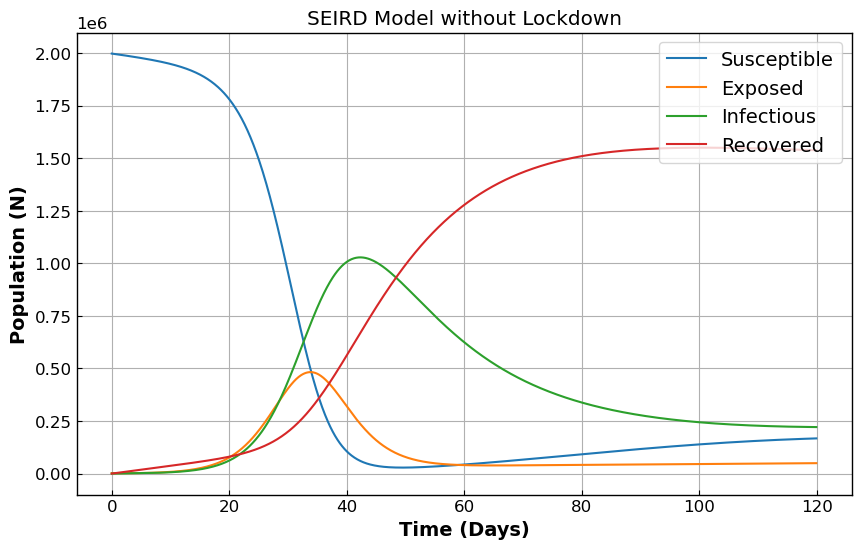

In [152]:
plot_solution_curves(T_no_lock, X_no_lock, "SEIRD Model without Lockdown")

#### Scenario 3: Lockdown with sharpness -0.04

In [153]:
# S, E, I, R, D
X0 = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]
sharpness = -0.04

# Solve ODE with 'Radau' or 'BDF' for stiff problems
sol_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=True, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T_Slow_lock, X_Slow_lock = sol_lock.t, sol_lock.y

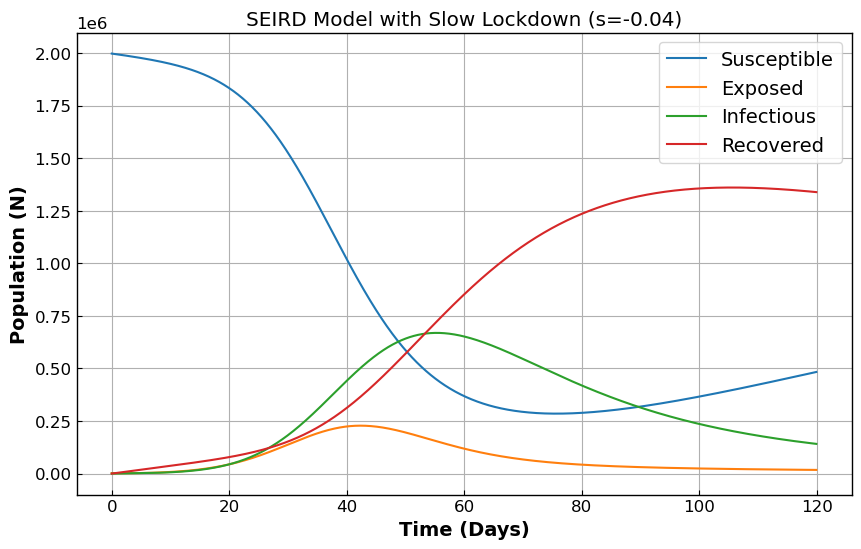

In [154]:
plot_solution_curves(
    T_Slow_lock, X_Slow_lock, "SEIRD Model with Slow Lockdown (s=-0.04)"
)

#### Productivity Computation

In [155]:
LOCKDOWN_START = 7

In [156]:
# Initialize Arrays
productivity_no_lockdown = np.zeros(int(Number_of_days / Time_step))
productivity_lockdown = np.zeros(int(Number_of_days / Time_step))
productivity_slow_lockdown = np.zeros(int(Number_of_days / Time_step))

# Variable to track quarentine days
lockdown_time = 0

# Run through all time points and sum the productivity arrays
for x in range(int(Number_of_days / Time_step)):

    # Productivity of no lockdown model
    productivity_no_lockdown[x] = (
        hevNoLockdown * (X[0][x] + X[3][x]) + iev * X[2][x] + eev * X[1][x]
    )

    # If there are infected individuals, the lockdown continues.
    # Sum productivities of slow lockdown and fast lockdown
    if x >= LOCKDOWN_START and X_lock[2][x] >= 1:
        productivity_lockdown[x] = (
            hevLockdown * X_lock[0][x]
            + iev * X_lock[2][x]
            + eev * X_lock[1][x]
            + X_lock[3][x]
        )
        productivity_slow_lockdown[x] = (
            hevLockdown * X_Slow_lock[0][x]
            + iev * X_Slow_lock[2][x]
            + eev * X_Slow_lock[1][x]
            + X_Slow_lock[3][x]
        )

    # If there are no infected individuals, the quarantine timer starts.
    elif x >= LOCKDOWN_START and lockdown_time < 140:
        productivity_lockdown[x] = (
            hevLockdown * X_lock[0][x]
            + iev * X_lock[2][x]
            + eev * X_lock[1][x]
            + X_lock[3][x]
        )
        productivity_slow_lockdown[x] = (
            hevLockdown * X_Slow_lock[0][x]
            + iev * X_Slow_lock[2][x]
            + eev * X_Slow_lock[1][x]
            + X_Slow_lock[3][x]
        )
        lockdown_time += 1

    # Once the quarantine timer expires, the population can leave lockdown
    else:
        productivity_lockdown[x] = (
            hevNoLockdown * (X_lock[0][x] + X_lock[3][x])
            + iev * X[2][x]
            + eev * X[1][x]
        )
        productivity_slow_lockdown[x] = (
            hevNoLockdown * (X_Slow_lock[0][x] + X_Slow_lock[3][x])
            + iev * X[2][x]
            + eev * X[1][x]
        )

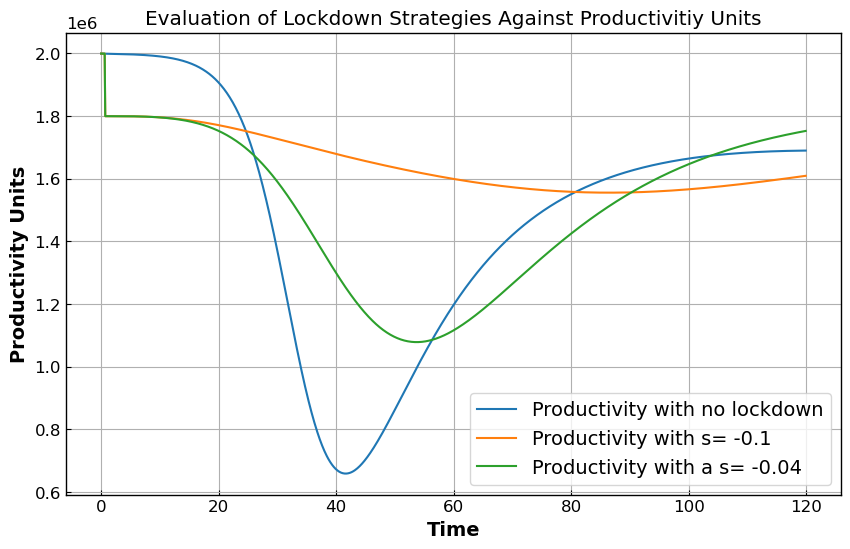

In [157]:
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(T_no_lock, productivity_no_lockdown, label="Productivity with no lockdown")
plt.plot(T_lock, productivity_lockdown, label="Productivity with s= -0.1")
plt.plot(T_Slow_lock, productivity_slow_lockdown, label="Productivity with a s= -0.04")
plt.xlabel("Time")
plt.ylabel("Productivity Units")
plt.title("Evaluation of Lockdown Strategies Against Productivitiy Units")
plt.legend()
plt.grid(True)
plt.savefig("./plots/productivity_of_lockdown_strategies.png")
plt.show()

### 2ii. 365 Days of Lockdown
- $(s=-0.1 ~\text{and}~ s=-.04)$ and Without Lockdown

In [158]:
Number_of_days = 365
Time_step = 0.1

tspan = (0, Number_of_days)
t_eval = np.arange(0, Number_of_days, Time_step)

#### Scenario 1: Lockdown with sharpness -0.1

In [159]:
# S, E, I, R, D
X0 = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]
sharpness = -0.1
sol_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=True, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T_lock, X_lock = sol_lock.t, sol_lock.y

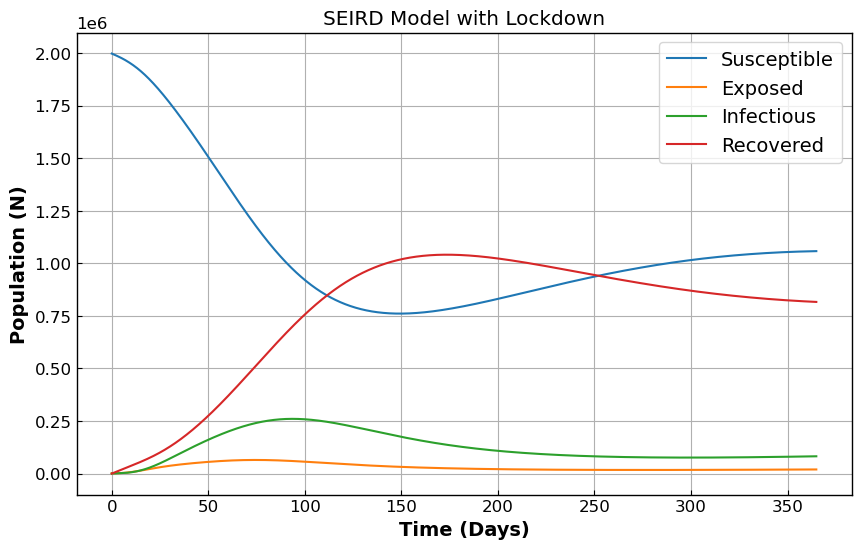

In [160]:
plot_solution_curves(T_lock, X_lock, "SEIRD Model with Lockdown")

#### Scenario 2: no Lockdown

In [161]:
# S, E, I, R, D
X0 = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]
sol_no_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=False, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T_no_lock, X_no_lock = sol_no_lock.t, sol_no_lock.y

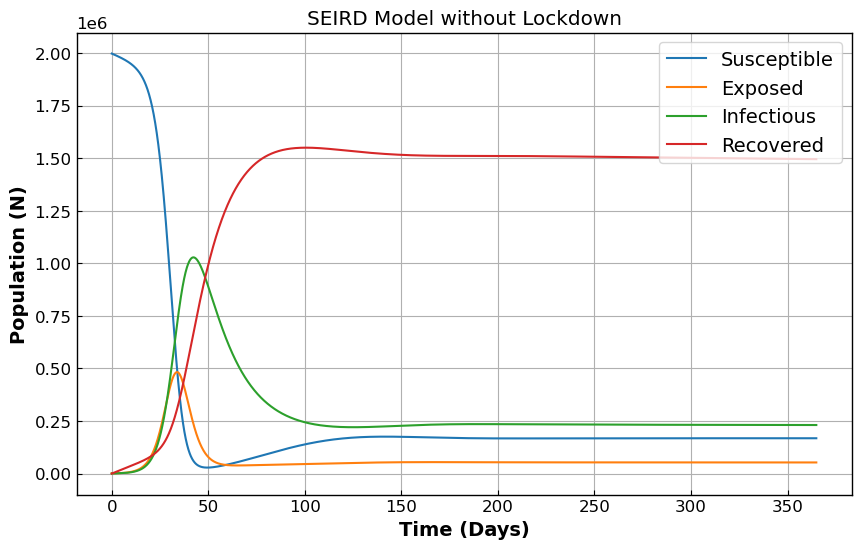

In [162]:
plot_solution_curves(T_no_lock, X_no_lock, "SEIRD Model without Lockdown")

#### Scenario 3: Lockdown with sharpness -0.04

In [163]:
# S, E, I, R, D
X0 = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]
sharpness = -0.04
sol_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=True, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T_Slow_lock, X_Slow_lock = sol_lock.t, sol_lock.y

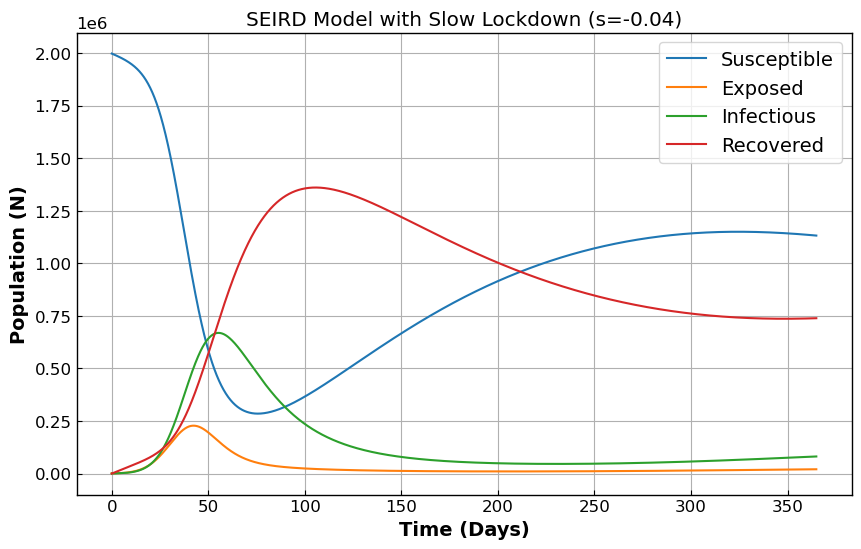

In [164]:
plot_solution_curves(
    T_Slow_lock, X_Slow_lock, "SEIRD Model with Slow Lockdown (s=-0.04)"
)

#### Productivity Computation

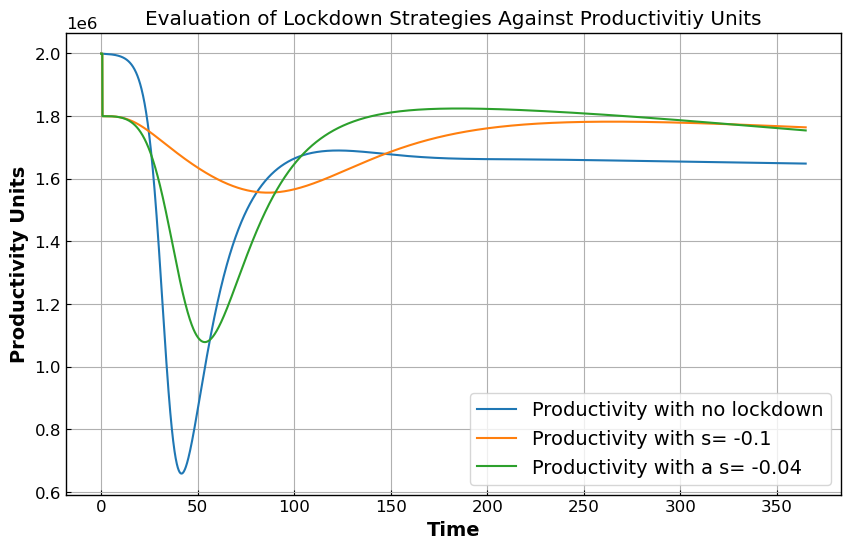

In [165]:
# Initialize Arrays
productivity_no_lockdown = np.zeros(int(Number_of_days / Time_step))
productivity_lockdown = np.zeros(int(Number_of_days / Time_step))
productivity_slow_lockdown = np.zeros(int(Number_of_days / Time_step))

# Variable to track quarentine days
lockdown_time = 0

# Run through all time points and sum the productivity arrays
for x in range(int(Number_of_days / Time_step)):

    # Productivity of no lockdown model
    productivity_no_lockdown[x] = (
        hevNoLockdown * (X_no_lock[0][x] + X_no_lock[3][x])
        + iev * X_no_lock[2][x]
        + eev * X_no_lock[1][x]
    )

    # If there are infected individuals, the lockdown continues.  Sum productivities of slow lockdown and fast lockdown
    if x >= LOCKDOWN_START and X_lock[2][x] >= 1:
        productivity_lockdown[x] = (
            hevLockdown * X_lock[0][x]
            + iev * X_lock[2][x]
            + eev * X_lock[1][x]
            + X_lock[3][x]
        )
        productivity_slow_lockdown[x] = (
            hevLockdown * X_Slow_lock[0][x]
            + iev * X_Slow_lock[2][x]
            + eev * X_Slow_lock[1][x]
            + X_Slow_lock[3][x]
        )

    # If there are no infected individuals, the quarantine timer starts.
    elif x >= LOCKDOWN_START and lockdown_time < 140:
        productivity_lockdown[x] = (
            hevLockdown * X_lock[0][x]
            + iev * X_lock[2][x]
            + eev * X_lock[1][x]
            + X_lock[3][x]
        )
        productivity_slow_lockdown[x] = (
            hevLockdown * X_Slow_lock[0][x]
            + iev * X_Slow_lock[2][x]
            + eev * X_Slow_lock[1][x]
            + X_Slow_lock[3][x]
        )
        lockdown_time += 1

    # Once the quarantine timer expires, the population can leave lockdown
    else:
        productivity_lockdown[x] = (
            hevNoLockdown * (X_lock[0][x] + X_lock[3][x])
            + iev * X[2][x]
            + eev * X[1][x]
        )
        productivity_slow_lockdown[x] = (
            hevNoLockdown * (X_Slow_lock[0][x] + X_Slow_lock[3][x])
            + iev * X[2][x]
            + eev * X[1][x]
        )

fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(T_lock, productivity_no_lockdown, label="Productivity with no lockdown")
plt.plot(T_lock, productivity_lockdown, label="Productivity with s= -0.1")
plt.plot(T_lock, productivity_slow_lockdown, label="Productivity with a s= -0.04")
plt.xlabel("Time")
plt.ylabel("Productivity Units")
plt.title("Evaluation of Lockdown Strategies Against Productivitiy Units")
plt.legend()
plt.grid(True)
plt.show()

### 2iii. 1000 Days of Lockdown
- $(s=-0.1 ~\text{and}~ s=-.04)$ and Without Lockdown

In [166]:
Number_of_days = 1000
Time_step = 0.1

# Time span for simulation is 120 days or roughly 4 months
tspan = (0, Number_of_days)
t_eval = np.arange(0, Number_of_days, Time_step)

#### Scenario 1: Lockdown with sharpness -0.1

In [167]:
# S, E, I, R, D
X0 = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]
sharpness = -0.1
sol_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=True, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T_lock, X_lock = sol_lock.t, sol_lock.y

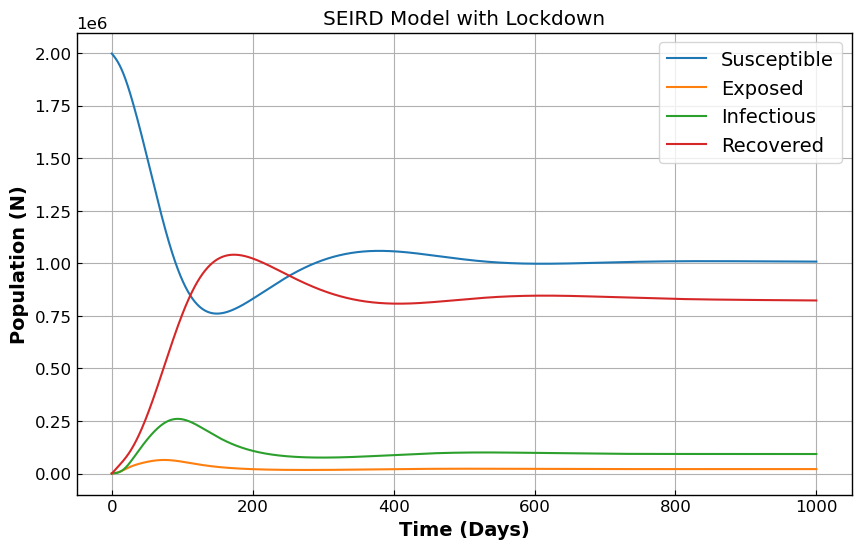

In [168]:
plot_solution_curves(T_lock, X_lock, "SEIRD Model with Lockdown")

#### Scenario 2: no Lockdown

In [169]:
# S, E, I, R, D
X0 = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]
sol_no_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=False, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T_no_lock, X_no_lock = sol_no_lock.t, sol_no_lock.y

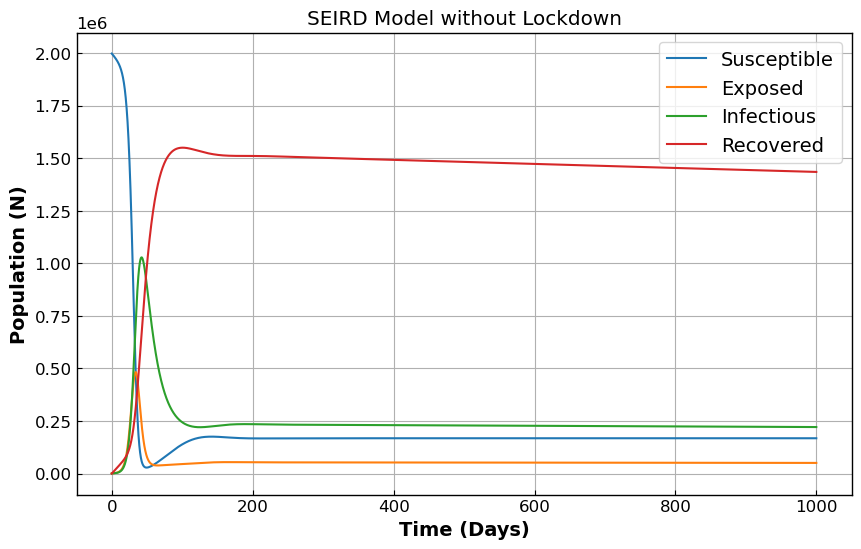

In [170]:
plot_solution_curves(T_no_lock, X_no_lock, "SEIRD Model without Lockdown")

#### Scenario 3: Lockdown with sharpness -0.04

In [171]:
# S, E, I, R, D
X0 = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]
sharpness = -0.04
sol_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=True, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T_Slow_lock, X_Slow_lock = sol_lock.t, sol_lock.y

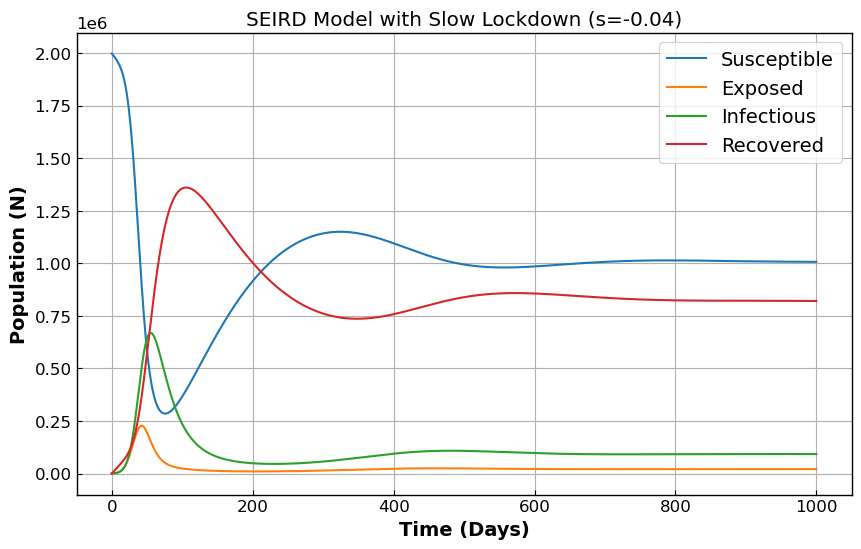

In [172]:
plot_solution_curves(
    T_Slow_lock, X_Slow_lock, "SEIRD Model with Slow Lockdown (s=-0.04)"
)

#### Productivity Computation

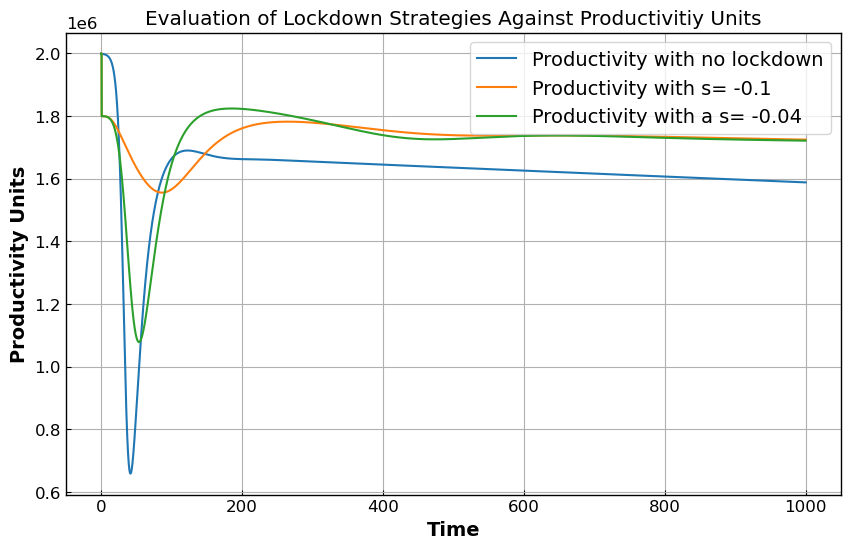

In [173]:
# Initialize Arrays
productivity_no_lockdown = np.zeros(int(Number_of_days / Time_step))
productivity_lockdown = np.zeros(int(Number_of_days / Time_step))
productivity_slow_lockdown = np.zeros(int(Number_of_days / Time_step))

# Variable to track quarentine days
lockdown_time = 0

# Run through all time points and sum the productivity arrays
for x in range(int(Number_of_days / Time_step)):

    # Productivity of no lockdown model
    productivity_no_lockdown[x] = (
        hevNoLockdown * (X_no_lock[0][x] + X_no_lock[3][x])
        + iev * X_no_lock[2][x]
        + eev * X_no_lock[1][x]
    )

    # If there are infected individuals, the lockdown continues.  Sum productivities of slow lockdown and fast lockdown
    if x >= LOCKDOWN_START and X_lock[2][x] >= 1:
        productivity_lockdown[x] = (
            hevLockdown * X_lock[0][x]
            + iev * X_lock[2][x]
            + eev * X_lock[1][x]
            + X_lock[3][x]
        )
        productivity_slow_lockdown[x] = (
            hevLockdown * X_Slow_lock[0][x]
            + iev * X_Slow_lock[2][x]
            + eev * X_Slow_lock[1][x]
            + X_Slow_lock[3][x]
        )

    # If there are no infected individuals, the quarantine timer starts.
    elif x >= LOCKDOWN_START and lockdown_time < 140:
        productivity_lockdown[x] = (
            hevLockdown * X_lock[0][x]
            + iev * X_lock[2][x]
            + eev * X_lock[1][x]
            + X_lock[3][x]
        )
        productivity_slow_lockdown[x] = (
            hevLockdown * X_Slow_lock[0][x]
            + iev * X_Slow_lock[2][x]
            + eev * X_Slow_lock[1][x]
            + X_Slow_lock[3][x]
        )
        lockdown_time += 1

    # Once the quarantine timer expires, the population can leave lockdown
    else:
        productivity_lockdown[x] = (
            hevNoLockdown * (X_lock[0][x] + X_lock[3][x])
            + iev * X[2][x]
            + eev * X[1][x]
        )
        productivity_slow_lockdown[x] = (
            hevNoLockdown * (X_Slow_lock[0][x] + X_Slow_lock[3][x])
            + iev * X[2][x]
            + eev * X[1][x]
        )

fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(T_lock, productivity_no_lockdown, label="Productivity with no lockdown")
plt.plot(T_lock, productivity_lockdown, label="Productivity with s= -0.1")
plt.plot(T_lock, productivity_slow_lockdown, label="Productivity with a s= -0.04")
plt.xlabel("Time")
plt.ylabel("Productivity Units")
plt.title("Evaluation of Lockdown Strategies Against Productivitiy Units")
plt.legend()
plt.grid(True)
plt.show()

## Section 3: Optimization

### 3i. Optimization Function Setup

In [174]:
def lockdown_intensity(t, sharpness, nc_min, nc_max=6):
    """Normalizes the contact rate nc to a value between 0 and 1.
    This is done via min-max scaling.
    """
    nc = nc_func(t, sharpness, nc_min, nc_max)
    return (nc_max - nc) / (nc_max - nc_min)

- Normalize the lockdown function to be between 0 and 1.
- This can be interpreted as the lockdown intensity, where 0 is no lockdown and 1 is a full lockdown.

In [175]:
def simulate_seird(sharpness, min_val, t_span, y0, pt, b, c, eta, gamma, nu, N):
    def rhs(t, X):
        nc = nc_func(t, sharpness, min_val)
        a = pt * nc
        s, e, i, r, d = X
        ds = -a * s * i / N - c * s + gamma * r
        de = a * s * i / N - nu * e
        di = nu * e - b * i - eta * i
        dr = b * i + c * s - gamma * r
        dd = eta * i
        return [ds, de, di, dr, dd]

    sol = solve_ivp(rhs, t_span, y0, t_eval=np.linspace(t_span[0], t_span[1], 400))
    return sol

In [176]:
# Constants
# units are in millions
GDP_PER_DAY = 750  # this is 750 million per day
VALUE_OF_LIFE = 15  # this is 15 million per life, using DoT valuation
HOSP_COST_PER_DAY = 0.015  # this is $15k per day for hospitalization

`GDP_PER_DAY`
- This computation started with GDP per capita data and then converted it to a daily rate.
- Example shown in Section 4i.

`VALUE_OF_LIFE`
- We use the Department of Transportation (DoT) valuation of a life, which is around \$14 million.

`HOSP_COST_PER_DAY`
- The paper finds the range of cost to be 10 - 13k. We use 15k just to be on the conservative side.
- Source
    - https://pmc.ncbi.nlm.nih.gov/articles/PMC10765267/

In [177]:
def total_cost(
    params,
    t_span,
    y0,
    pt,
    b,
    c,
    eta,
    gamma,
    nu,
    N,
    hospital_capacity,
    GDP_PER_DAY,
    VALUE_OF_LIFE,
):
    sharpness, min_val = params

    # Run simulation
    sol = simulate_seird(sharpness, min_val, t_span, y0, pt, b, c, eta, gamma, nu, N)
    t = sol.t

    # 1. Death Cost (in $M)
    death_cost = sol.y[4][-1] * VALUE_OF_LIFE

    # 2. Economic Cost ($M)
    lockdown_values = [lockdown_intensity(ti, sharpness, min_val) for ti in t]
    # ∫(intensity) dt * GDP
    econ_cost = np.trapz(lockdown_values, t) * GDP_PER_DAY

    # 3. Hospital Penalty (in $M)
    # y is SEIRD, so y[2] is the number of infected
    excess_hosp = np.maximum(sol.y[2] - hospital_capacity, 0)
    hosp_penalty = np.trapz(excess_hosp, t) * HOSP_COST_PER_DAY

    return death_cost + econ_cost + hosp_penalty

- The total cost function is defined as the sum of three components:
    - 1. Death Cost (in $M)
    - 2. Economic Cost ($M)
    - 3. Hospital Penalty (in $M)

### 3ii. Solve the Optimization Problem

In [178]:
# Parameters
# Time span for simulation is 120 days or
# roughly 4 months
tspan = (0, 120)
t_eval = np.arange(0, 120, 0.1)
# Population size
N = 2e6
# nc ranges from 6 to 1
# vary this to match the R0
pt = 0.1
# research found ranges from 0.03 to 0.06
b = 0.05
# The vacinnation rate from 2020-2021 was around 0.013
VAX_RATE = 0.69  # per year
c = VAX_RATE / (365)
# the death rate from infected was 0.008 but we round
DEATH_RATE = 0.01
eta = DEATH_RATE * b / (1 - DEATH_RATE)
gamma = 0.008
nu = 0.22
# Patient 0 scenario
X0 = [N - 1, 1, 0, 0, 0]

# Hospital capacity is 0.3% of the population
hospital_capacity = N * 0.003

In [179]:
# Bounds:
# sharpness ∈ [-1, -0.01] (negative, more negative = faster lockdown)
# min_val ∈ [1, 4] (reasonable range for lockdown strength)
bounds = [(-2, -0.001), (1, 4)]

# Initial guess
initial_guess = [-0.02, 3]  # [sharpness, min_val]

# Fixed parameters
args = (
    tspan,
    X0,
    pt,
    b,
    c,
    eta,
    gamma,
    nu,
    N,
    hospital_capacity,
    GDP_PER_DAY,
    VALUE_OF_LIFE,
)

# Run optimization
res = minimize(
    total_cost,
    initial_guess,
    args=args,
    method="L-BFGS-B",
    bounds=bounds,
    options={"disp": True, "ftol": 1e-8, "maxiter": 1000},  # Smaller = more precise
)

print(f"Optimal sharpness: {res.x[0]:.4f}, min_val: {res.x[1]:.4f}")
print(f"Minimum cost: {res.fun:.2f}")

Optimal sharpness: -0.0489, min_val: 1.0000
Minimum cost: 71695.07


### 3iii. Visualization

- Since the optimal minimum number of contacts is 1, we'll not plot it. Instead, we will plot total cost versus the sharpness of the lockdown.
- We see that there is indeed a minimum point in the cost function.

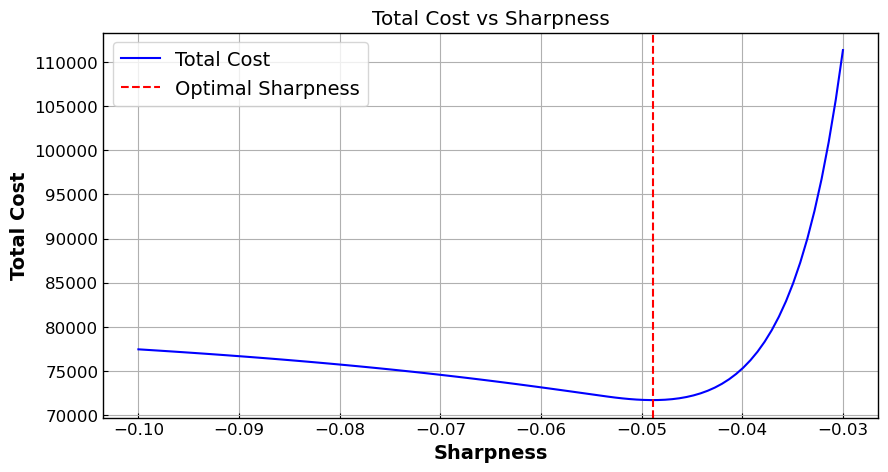

In [180]:
# plot total cost as a function of sharpness
sharpness_values = np.linspace(-2, -0.001, 100)
sharpness_values = np.linspace(-0.1, -0.03, 100)
min_val_fixed = res.x[1]
total_costs = [
    total_cost(
        [sharpness, min_val_fixed],
        tspan,
        X0,
        pt,
        b,
        c,
        eta,
        gamma,
        nu,
        N,
        hospital_capacity,
        GDP_PER_DAY,
        VALUE_OF_LIFE,
    )
    for sharpness in sharpness_values
]


plt.figure(figsize=(10, 5))
plt.plot(sharpness_values, total_costs, label="Total Cost", color="blue")
plt.axvline(res.x[0], color="red", linestyle="--", label="Optimal Sharpness")
plt.xlabel("Sharpness")
plt.ylabel("Total Cost")
plt.title("Total Cost vs Sharpness")
plt.legend()
plt.grid()
plt.savefig("./plots/optimum.png")
plt.show()

## Section 4: Sensitivity Analysis

### 4i. GDP

$$
\text{GDP per capita} = \text{GDP PER DAY} * 365 / N
$$

In [181]:
gdp_values = np.logspace(np.log10(50), np.log10(1000), 50)
# GDP per capita in millions
gdp_values * 365 / N

array([0.009125  , 0.00970029, 0.01031184, 0.01096195, 0.01165304,
       0.01238771, 0.01316869, 0.01399891, 0.01488147, 0.01581968,
       0.01681703, 0.01787725, 0.01900433, 0.02020245, 0.02147612,
       0.02283008, 0.0242694 , 0.02579946, 0.02742599, 0.02915506,
       0.03099314, 0.0329471 , 0.03502425, 0.03723235, 0.03957966,
       0.04207496, 0.04472757, 0.04754742, 0.05054504, 0.05373165,
       0.05711917, 0.06072024, 0.06454835, 0.06861779, 0.0729438 ,
       0.07754254, 0.0824312 , 0.08762808, 0.09315258, 0.09902539,
       0.10526844, 0.11190508, 0.11896013, 0.12645997, 0.13443263,
       0.14290793, 0.15191756, 0.16149519, 0.17167665, 0.1825    ])

- Using GDP per capita data from Wikipedia, we can back out the value for GDP PER DAY.
- Above is an example of how we go from GDP per day to GDP per capita (units are in millions).
- The range is from 9k (small, rural areas) to 182k (large, urban areas).

    - Source
        - https://en.wikipedia.org/wiki/List_of_U.S._metropolitan_areas_by_GDP_per_capita


In [182]:
tspan = (0, 120)
t_eval = np.arange(0, 120, 0.1)
# Population size
N = 2e6
# probability of transmission
pt = 0.1
# recovery rate
b = 0.05
# The vacinnation rate
VAX_RATE = 0.69  # per year
c = VAX_RATE / (365)
# Death rate
DEATH_RATE = 0.01
eta = DEATH_RATE * b / (1 - DEATH_RATE)
# Mutation rate
gamma = 0.008
# latent period
nu = 0.22
# Patient 0 scenario
X0 = [N - 1, 1, 0, 0, 0]

- Reinitializing the parameters for the sensitivity analysis. To ensure reproducibility.

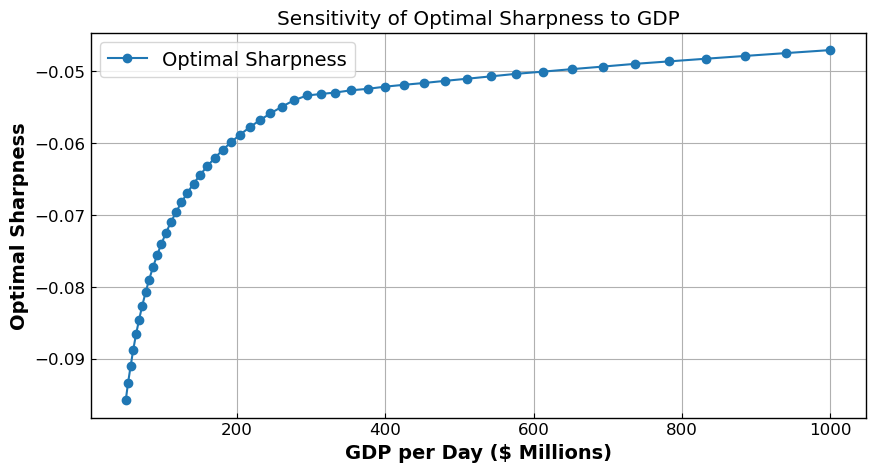

In [183]:
# sensitivity of optimal sharpness for GDP
gdp_values = np.logspace(np.log10(50), np.log10(1000), 50)
optimal_sharpness = []
for gdp in gdp_values:
    args = (
        tspan,
        X0,
        pt,
        b,
        c,
        eta,
        gamma,
        nu,
        N,
        hospital_capacity,
        gdp,
        VALUE_OF_LIFE,
    )
    res = minimize(
        total_cost,
        initial_guess,
        args=args,
        method="L-BFGS-B",
        bounds=bounds,
        options={"disp": True},
    )
    optimal_sharpness.append(res.x[0])

plt.figure(figsize=(10, 5))
plt.plot(gdp_values, optimal_sharpness, marker="o", label="Optimal Sharpness")
plt.xlabel("GDP per Day ($ Millions)")
plt.ylabel("Optimal Sharpness")
plt.title("Sensitivity of Optimal Sharpness to GDP")
plt.grid()
plt.legend()
plt.savefig("./plots/gdp_sensitivity.png")
plt.show()

- As the GDP per day increases, the optimal sharpness of the lockdown becomes less negative or shallower. 
- If we value the economy more, we want a slower lockdown to preserve economic health.


### 4ii. Value of Life

In [184]:
tspan = (0, 120)
t_eval = np.arange(0, 120, 0.1)
# Population size
N = 2e6
# probability of transmission
pt = 0.1
# recovery rate
b = 0.05
# The vacinnation rate
VAX_RATE = 0.69  # per year
c = VAX_RATE / (365)
# Death rate
DEATH_RATE = 0.01
eta = DEATH_RATE * b / (1 - DEATH_RATE)
# Mutation rate
gamma = 0.008
# latent period
nu = 0.22
# Patient 0 scenario
X0 = [N - 1, 1, 0, 0, 0]

- Reinitializing the parameters for the sensitivity analysis. To ensure reproducibility.

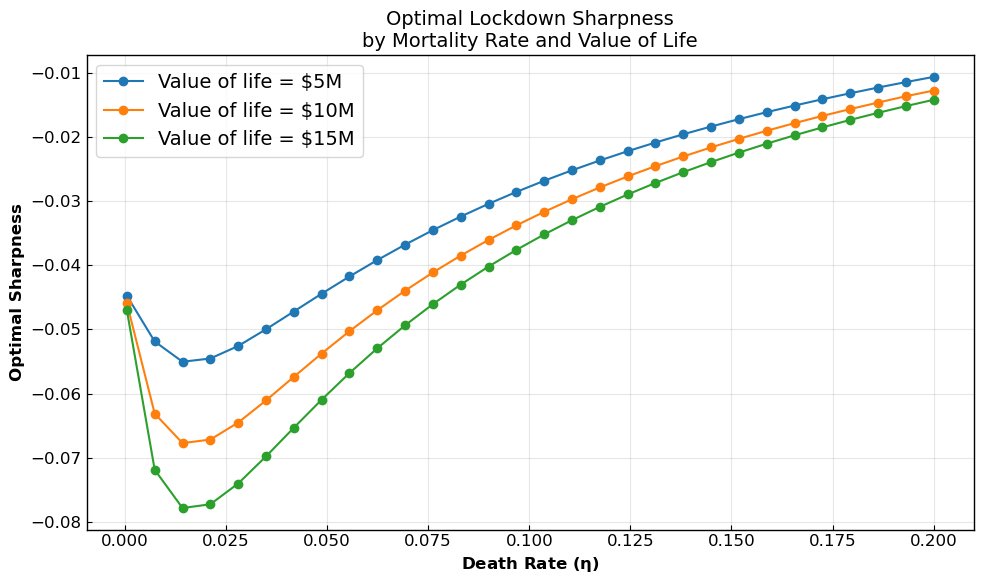

In [185]:
# Setup
eta_values = np.linspace(0.0005, 0.2, 30)
val_life_list = [5, 10, 15]  # Different values of life in millions
GDP_PER_DAY = 1000
plt.figure(figsize=(10, 6))

# Color palette for distinct lines
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for val_life, color in zip(val_life_list, colors):
    optimal_sharpness_eta = np.zeros(len(eta_values))

    for i, eta in enumerate(eta_values):
        res = minimize(
            total_cost,
            initial_guess,
            args=(
                tspan,
                X0,
                pt,
                b,
                c,
                eta,
                gamma,
                nu,
                N,
                hospital_capacity,
                GDP_PER_DAY,
                val_life,
            ),
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "gtol": 1e-8,
                "maxiter": 1000,
                "finite_diff_rel_step": 1e-5,
            },
        )
        optimal_sharpness_eta[i] = res.x[0]

    # Plot all lines on same figure
    plt.plot(
        eta_values,
        optimal_sharpness_eta,
        marker="o",
        linestyle="-",
        color=color,
        label=f"Value of life = ${val_life}M",
    )

# Formatting
plt.xlabel("Death Rate ($\\eta$)", fontsize=12)
plt.ylabel("Optimal Sharpness", fontsize=12)
plt.title(
    "Optimal Lockdown Sharpness\nby Mortality Rate and Value of Life",
    fontsize=14,
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("./plots/death_sensitivity.png")
plt.show()

### 4iii. Probability of Transmission

In [186]:
tspan = (0, 120)
t_eval = np.arange(0, 120, 0.1)
# Population size
N = 2e6
# probability of transmission
pt = 0.1
# recovery rate
b = 0.05
# The vacinnation rate
VAX_RATE = 0.69  # per year
c = VAX_RATE / (365)
# Death rate
DEATH_RATE = 0.01
eta = DEATH_RATE * b / (1 - DEATH_RATE)
# Mutation rate
gamma = 0.008
# latent period
nu = 0.22
# Patient 0 scenario
X0 = [N - 1, 1, 0, 0, 0]

- Reinitializing the parameters for the sensitivity analysis. To ensure reproducibility.

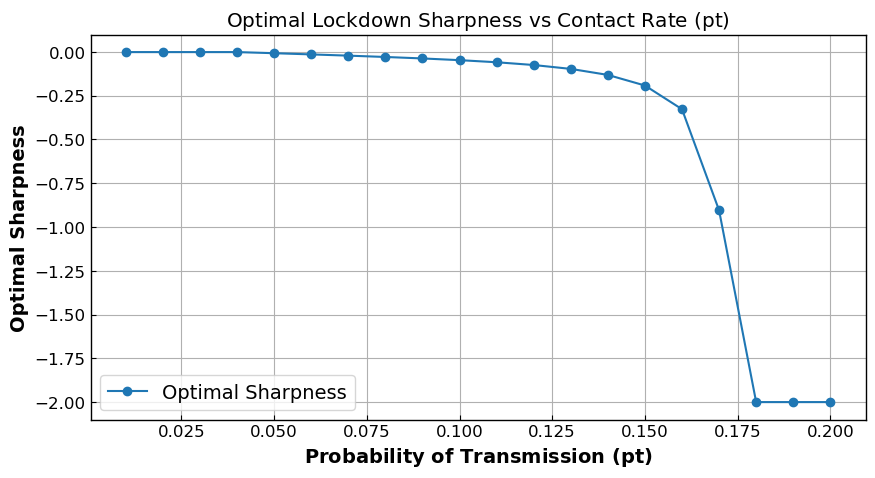

In [187]:
num_candidates = 20
optimal_sharpness_pt = np.zeros(num_candidates)
pts = np.linspace(0.01, 0.2, num_candidates)
GDP_PER_DAY = 1000
for i, pt in enumerate(pts):
    res = basinhopping(
        lambda x: total_cost(
            x,
            tspan,
            X0,
            pt,
            b,
            c,
            eta,
            gamma,
            nu,
            N,
            hospital_capacity,
            GDP_PER_DAY,
            VALUE_OF_LIFE=VALUE_OF_LIFE,
        ),
        initial_guess,
        minimizer_kwargs={"method": "L-BFGS-B", "bounds": bounds},
        niter=10,
        stepsize=0.1,
    )
    optimal_sharpness_pt[i] = res.x[0]
plt.figure(figsize=(10, 5))
plt.plot(pts, optimal_sharpness_pt, marker="o", label="Optimal Sharpness")
plt.xlabel("Probability of Transmission ($pt$)")
plt.ylabel("Optimal Sharpness")
plt.title("Optimal Lockdown Sharpness vs Contact Rate ($pt$)")
plt.grid()
plt.legend()
plt.savefig("./plots/pt_sensitivity.png")
plt.show()

- Once $pt$ gets high enough the optimal sharpness is at the boundary which is -2 for this case.